# What actually drives engagement? Stanbic IBTC social media, 2017 to mid-2023

This notebook rebuilds the original hackathon analysis with three rules:

1. **Compare like with like.** Totals mostly measure how often something was posted. Every comparison here is per post (medians) or a rate that adjusts for delivery (engagements per impression).
2. **Never repair data by guessing.** Rows that cannot be true are excluded and counted. Metrics a platform does not report stay missing.
3. **Separate what the data shows from what it can explain.** Associations are reported with confidence intervals and effect sizes. Causal language is avoided because this is observational data.

The cleaning rules live in `src/clean.py` and the statistical helpers in `src/stats.py`.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error

import clean, stats, style
style.apply()
pd.set_option("display.precision", 2)
FIG = "../figures/"
ORDER = style.NETWORK_ORDER

## 1. Data quality and cleaning

The raw exports cover 36,092 posts from four platforms. Before any analysis, each exclusion rule is applied in order and logged.

In [2]:
posts, log = clean.build()
log.pivot_table(index="step", columns="network", values="rows", sort=False)

network,Facebook,Twitter,Instagram,LinkedIn
step,,,,
Raw export,9803.0,8529.0,10000.0,7760.0
Unreadable date,9803.0,8529.0,10000.0,7760.0
No metrics recorded (impressions missing),8893.0,7842.0,8516.0,6332.0
Zero impressions (post never delivered),7713.0,7841.0,8227.0,6332.0
Negative or missing engagements (export error),7713.0,7841.0,8227.0,6330.0
"Engagements exceed impressions (impossible, export error)",7690.0,7840.0,8129.0,6264.0
Content type with <5 posts,7690.0,7840.0,8129.0,6261.0


**What the log shows**

* **Missing metrics.** Between 8% and 18% of posts per platform have no impressions or engagements at all. These are posts the export recorded without performance data. They cannot be imputed honestly, so they are removed rather than filled with zero.
* **Impossible values.** 188 posts report more engagements than impressions, and 2 LinkedIn posts report negative engagements. The original analysis flipped negatives to positive with `abs()`, which turns an error into invented data. Here they are excluded.
* **Dates.** 3,978 Facebook dates had been re-saved by a spreadsheet in a different format. They are recovered (see `clean.parse_dates`) rather than dropped.
* **Coverage.** Very few posts with metrics exist before 2017, and 2023 stops in July. The analysis therefore uses **2017 onwards**, and 2023 is always labelled as a partial year.

In [3]:
d = posts[posts["year"] >= 2017].copy()
# Year-adjusted index: a post's engagement rate divided by the median rate of its
# platform in that year. 1.0 = a typical post for that platform and year. This stops
# long-run drift in platform algorithms from masquerading as a content effect.
d["er_index"] = d["er"] / d.groupby(["network", "year"])["er"].transform("median")

overview = d.groupby("network").agg(
    posts=("er", "size"),
    first=("posted_at", "min"),
    last=("posted_at", "max"),
    median_impressions=("impressions", "median"),
    median_engagement_rate=("er", "median"),
).loc[ORDER]
overview

,posts,first,last,median_impressions,median_engagement_rate
network,,,,,
Facebook,7679,2017-03-15 20:11:00,2023-07-13 10:08:00,4689.0,2.57
Instagram,8093,2017-01-01 00:33:00,2023-07-13 12:03:00,2069.0,3.02
LinkedIn,6261,2018-02-14 14:45:00,2023-07-12 19:00:00,783.0,2.65
Twitter,7153,2017-01-01 00:00:00,2023-07-13 10:57:00,2557.0,2.48


## 2. Content type: volume is not performance

The original report ranked photos as the most engaging format because photos collected the most engagements in total. Photos are also 75% to 85% of everything posted, so that ranking mainly reflects volume. The fair question is how a typical photo performs against a typical video.

In [4]:
ct = []
for net, g in d.groupby("network"):
    share = g.groupby("content_type")["engagements"].sum() / g["engagements"].sum() * 100
    s = stats.summarise(g, "content_type")
    s["network"] = net
    s["share_of_total_engagements"] = s["content_type"].map(share)
    s["share_of_posts"] = s["content_type"].map(g["content_type"].value_counts(normalize=True) * 100)
    ct.append(s)
ct = pd.concat(ct)[["network", "content_type", "posts", "share_of_posts",
                    "share_of_total_engagements", "median", "ci_low", "ci_high", "reliable"]]
ct.rename(columns={"median": "median_er"})

,network,content_type,posts,share_of_posts,share_of_total_engagements,median_er,ci_low,ci_high,reliable
0,Facebook,Link,80,1.04,0.84,2.45,1.99,2.94,True
1,Facebook,Photo,6450,84.00,85.77,2.40,2.36,2.44,True
2,Facebook,Text,264,3.44,6.0,2.83,2.44,3.22,True
3,Facebook,Video,885,11.52,7.39,4.50,4.30,4.63,True
0,Instagram,Carousel,725,8.96,10.06,3.44,3.33,3.53,True
1,Instagram,Photo,6446,79.65,78.35,2.95,2.91,2.98,True
2,Instagram,Video,922,11.39,11.59,3.12,3.04,3.21,True
0,LinkedIn,Link,31,0.50,0.47,3.08,2.57,3.89,True
1,LinkedIn,Photo,5176,82.67,87.73,2.82,2.79,2.87,True
2,LinkedIn,Text,208,3.32,2.55,1.24,1.05,1.38,True


In [5]:
effects = pd.DataFrame({n: stats.kruskal_epsilon(g, "content_type") for n, g in d.groupby("network")}).T
effects[["n", "groups", "H", "p", "epsilon_sq"]]

,n,groups,H,p,epsilon_sq
Facebook,7679.0,4.0,984.89,3.41e-213,1.28e-01
Instagram,8093.0,3.0,69.78,7.05e-16,8.62e-03
LinkedIn,6261.0,4.0,615.12,5.30e-133,9.83e-02
Twitter,7153.0,4.0,418.95,1.74e-90,5.86e-02


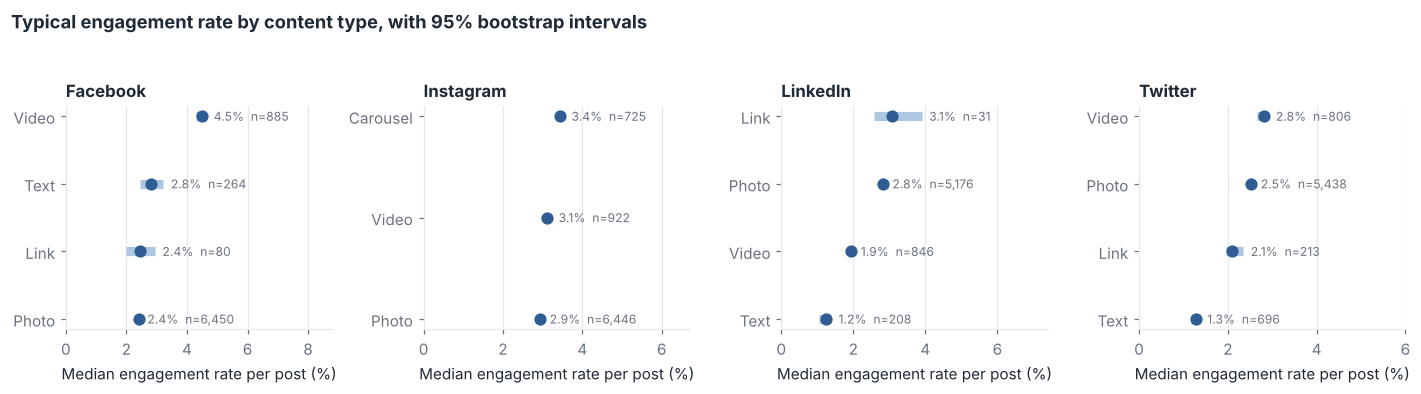

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=False)
for ax, net in zip(axes, ORDER):
    s = ct[(ct.network == net)].sort_values("median")
    y = np.arange(len(s))
    ax.hlines(y, s.ci_low, s.ci_high, color=style.LIGHT, lw=6)
    ax.plot(s["median"], y, "o", color=style.PRIMARY, ms=7)
    for yi, (_, r) in zip(y, s.iterrows()):
        flag = "" if r.reliable else " (few posts)"
        ax.annotate(f"{r['median']:.1f}%  n={r.posts:,}{flag}", (r.ci_high, yi),
                    xytext=(5, 0), textcoords="offset points", va="center", fontsize=8, color=style.MUTED)
    ax.set_yticks(y, s.content_type)
    ax.set_title(net)
    ax.set_xlim(0, max(6, s.ci_high.max() * 1.9))
    ax.set_xlabel("Median engagement rate per post (%)")
    ax.grid(axis="y", visible=False)
fig.suptitle("Typical engagement rate by content type, with 95% bootstrap intervals",
             x=0.01, ha="left", fontsize=12, fontweight="bold", y=1.04)
fig.tight_layout()
fig.savefig(FIG + "01_content_type_per_post.png")

**Reading it**

* On **Facebook**, a typical video earns an engagement rate of about 4.5%, almost double a typical photo (about 2.4%). Photos collected 86% of all Facebook engagements only because they were 84% of posts. The original ranking had the order the wrong way round for the format that performs best per post. One caution: Facebook videos reach far fewer people (median 1,595 impressions against 5,222 for photos), so a higher rate on a smaller audience is a trade-off, not a free win.
* On **Twitter**, photo and video posts clearly outperform plain text and link posts.
* On **LinkedIn**, the pattern reverses: photos (and the few link posts) lead, while video and text trail.
* On **Instagram**, the differences are real but small (epsilon squared below 0.01), so format choice matters least there.

The effect sizes are moderate at best (epsilon squared 0.06 to 0.13 on Facebook, LinkedIn and Twitter). Format matters, but most of the variation between posts is explained by other things.

## 3. Trends over time, and the COVID-19 claim

The original report described a surge in engagement in 2020 "during the peak of the COVID-19 pandemic". That conclusion came from yearly totals. Posting volume also rose by 46% to 65% in 2020 on every platform, so totals would rise even if each post performed exactly the same.

In [7]:
yr = d.groupby(["network", "year"]).agg(
    posts=("er", "size"),
    median_er=("er", "median"),
    median_impressions=("impressions", "median"),
).reset_index()
yr.pivot(index="year", columns="network", values=["posts", "median_er", "median_impressions"]).round(1)

posts                            median_er                     \
network Facebook Instagram LinkedIn Twitter  Facebook Instagram LinkedIn   
year                                                                       
2017         428       910      NaN     995      2.79      4.24      NaN   
2018         970       972      673     941       2.6      3.99      2.6   
2019         966       931      856     885      2.12      3.61     2.37   
2020        1475      1518     1247    1458      3.13      3.02     2.93   
2021        1411      1448     1302     593      2.02      2.39      2.8   
2022        1607      1645     1489    1529      2.41      2.29     2.69   
2023         822       669      694     752      3.34      2.69      2.1   

                median_impressions                             
network Twitter           Facebook Instagram LinkedIn Twitter  
year                                                           
2017       1.89             7699.5    1550.5      NaN  1531.0  
2018       2.22             5120.5    2160.0   1221.0  3052.0  
2019       2.28             9875.5    2615.0   1298.0  3269.0  
2020       2.88             6528.0    2840.5    824.0  4132.5  
2021       2.33             3725.0    2085.0    625.0  2950.0  
2022       2.68             3359.0    1459.0    547.0  1187.0  
2023       2.47             4043.0    1225.0    571.0  1739.5

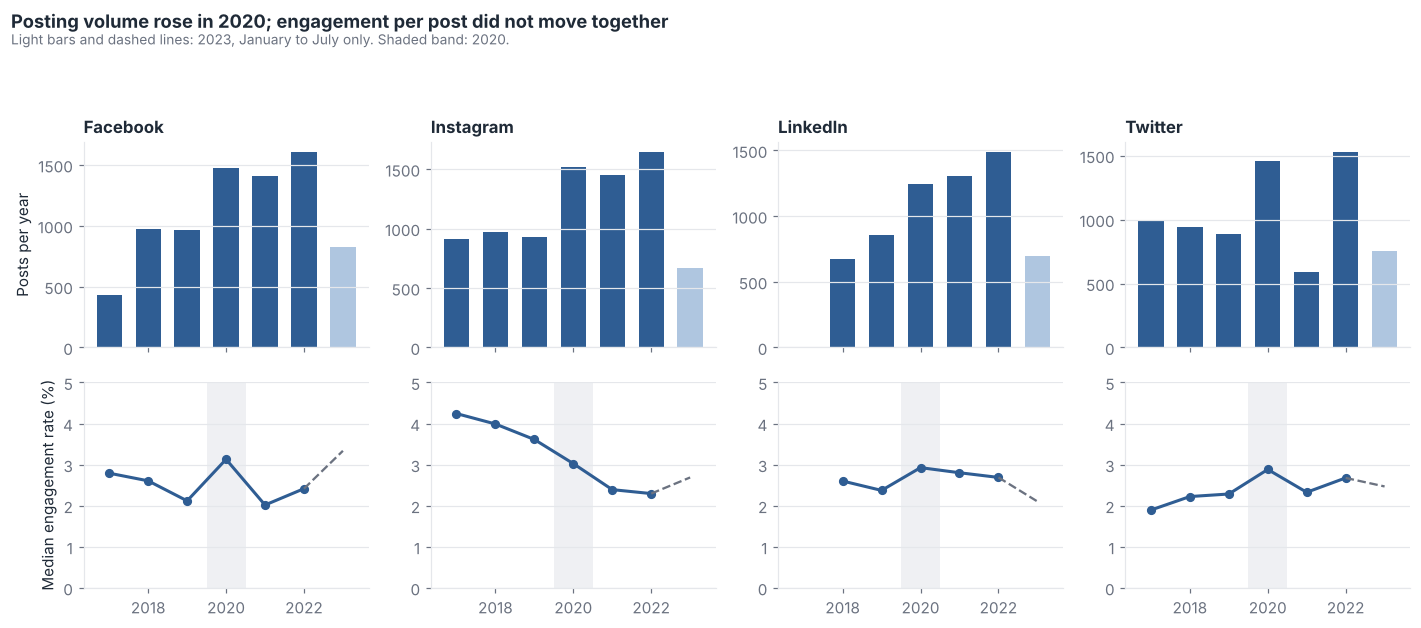

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5.2), sharex=True)
for i, net in enumerate(ORDER):
    s = yr[yr.network == net]
    full = s[s.year < 2023]
    for row, col, label in [(0, "posts", "Posts per year"), (1, "median_er", "Median engagement rate (%)")]:
        ax = axes[row, i]
        if row == 0:
            ax.bar(full.year, full[col], color=style.PRIMARY, width=0.65)
            ax.bar(s[s.year == 2023].year, s[s.year == 2023][col], color=style.LIGHT, width=0.65)
        else:
            ax.plot(full.year, full[col], "-o", color=style.PRIMARY, lw=2, ms=5)
            ax.plot(s[s.year >= 2022].year, s[s.year >= 2022][col], "--", color=style.MUTED, lw=1.5)
            ax.set_ylim(0, 5)
            ax.axvspan(2019.5, 2020.5, color=style.GRID, alpha=0.6, lw=0)
        if i == 0:
            ax.set_ylabel(label)
        ax.set_title(net if row == 0 else "")
        ax.grid(axis="x", visible=False)
fig.suptitle("Posting volume rose in 2020; engagement per post did not move together",
             x=0.01, ha="left", fontsize=12, fontweight="bold", y=1.09)
fig.text(0.01, 1.03, "Light bars and dashed lines: 2023, January to July only. Shaded band: 2020.",
         fontsize=9, color=style.MUTED)
fig.tight_layout()
fig.savefig(FIG + "02_trends_volume_vs_rate.png")

**Reading it**

* Per post, 2020 was better than 2019 on Facebook, LinkedIn and Twitter, but **worse on Instagram**. A single shared shock would not normally push platforms in opposite directions.
* **Instagram** shows the clearest long-run trend: the typical engagement rate fell steadily from 4.2% in 2017 to 2.3% in 2022. 2020 sits on that downward path rather than standing out from it.
* **Reach per post** has also fallen since 2019 or 2020 on every platform (median impressions per post fell by about half or more from each platform's 2019 or 2020 peak to 2022), even as the team posted more. That is consistent with more posts competing for the same audience, though this data cannot confirm it.
* COVID-19 may have played a part, but this data cannot separate it from posting volume, campaign mix or platform algorithm changes in the same year. The finding is reported as a timing coincidence, not a cause.
* The original "decline in 2023" is an artefact: 2023 only runs to July.

## 4. Posting time

The original analysis recommended posting at 10am because 10am posts had the most impressions in total. 10am is also the hour with by far the most posts, so the total says more about the team's schedule than about the audience. Here the posting hour is compared per post, and hours with fewer than 30 posts are shown but not interpreted.

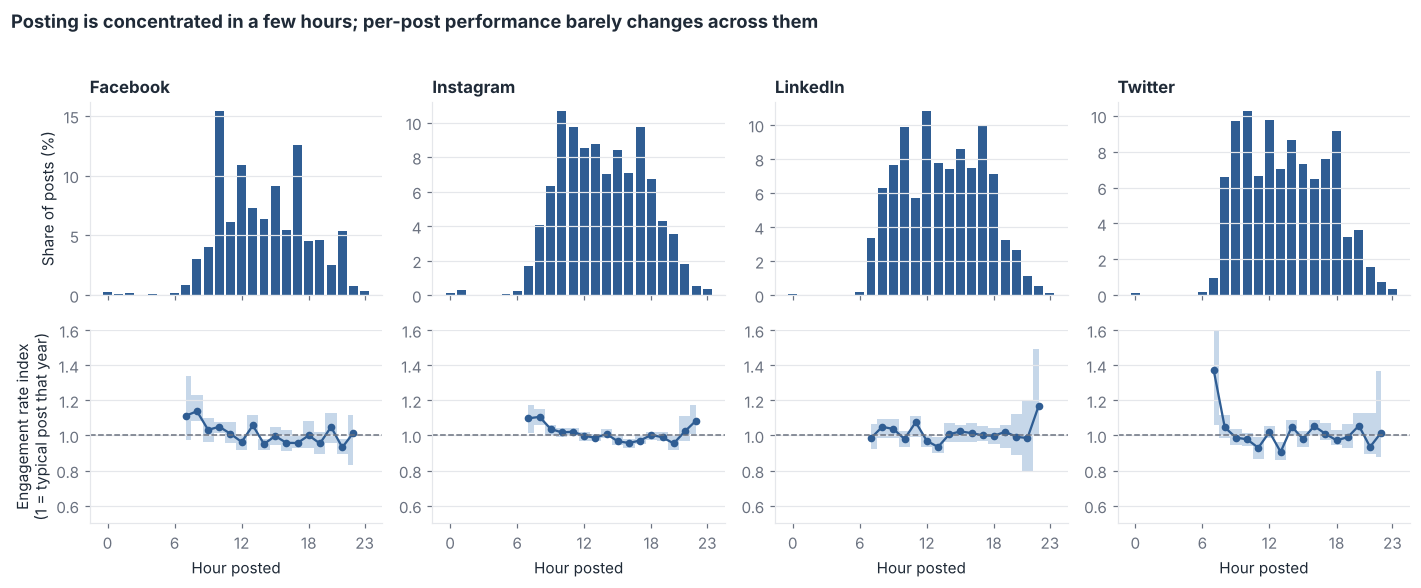

In [9]:
hr = []
for net, g in d.groupby("network"):
    s = stats.summarise(g, "hour", value="er_index")
    s["network"] = net
    s["share_of_posts"] = s["posts"] / s["posts"].sum() * 100
    hr.append(s)
hr = pd.concat(hr)

fig, axes = plt.subplots(2, 4, figsize=(13, 5.2), sharex=True)
for i, net in enumerate(ORDER):
    s = hr[hr.network == net]
    ok = s[s.reliable]
    axes[0, i].bar(s.hour, s.share_of_posts, color=style.PRIMARY, width=0.8)
    axes[0, i].set_title(net)
    ax = axes[1, i]
    ax.fill_between(ok.hour, ok.ci_low, ok.ci_high, color=style.LIGHT, alpha=0.7, lw=0, step="mid")
    ax.plot(ok.hour, ok["median"], "o-", color=style.PRIMARY, ms=4, lw=1.5)
    ax.axhline(1, color=style.MUTED, lw=1, ls="--")
    ax.set_ylim(0.5, 1.6)
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.set_xlabel("Hour posted")
    for a in axes[:, i]:
        a.grid(axis="x", visible=False)
axes[0, 0].set_ylabel("Share of posts (%)")
axes[1, 0].set_ylabel("Engagement rate index\n(1 = typical post that year)")
fig.suptitle("Posting is concentrated in a few hours; per-post performance barely changes across them",
             x=0.01, ha="left", fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIG + "03_posting_hour.png")

In [10]:
hr = hr.reset_index(drop=True)
spread = hr[hr.reliable].groupby("network")["median"].agg(["min", "max"])
peak = hr.loc[hr.groupby("network")["posts"].idxmax(), ["network", "hour", "share_of_posts", "median", "ci_low", "ci_high"]]
peak = peak.rename(columns={"hour": "busiest_hour", "median": "index_at_busiest_hour"}).set_index("network")
peak.join(spread.rename(columns={"min": "lowest_hour_index", "max": "highest_hour_index"})).loc[ORDER]

,busiest_hour,share_of_posts,index_at_busiest_hour,ci_low,ci_high,lowest_hour_index,highest_hour_index
network,,,,,,,
Facebook,10,15.38,1.05,1.02,1.08,0.93,1.14
Instagram,10,10.65,1.02,0.99,1.04,0.95,1.11
LinkedIn,12,10.80,0.97,0.94,1.00,0.93,1.17
Twitter,10,10.25,0.98,0.94,1.01,0.91,1.38


**Reading it**

* The busiest posting hour on each platform performs within about 5% of a typical post. The original 10am recommendation describes when the team already posted, not evidence that 10am works better.
* Across the hours with enough posts, most sit within about 10% of a typical post.
* The one consistent pattern is that **early-morning posts (7am to 8am) do somewhat better** on Facebook, Instagram and Twitter. Few posts go out then and the intervals are wide, so this is a candidate for a scheduling test, not a rule.
* Timestamps are taken as exported (assumed West Africa Time), which is a further reason not to over-read any single hour.

## 5. Does reach come with engagement?

The original report stated "a positive correlation between engagement rates and impressions" without computing one. Spearman's rank correlation is used here because both measures are heavily skewed.

In [11]:
corr = pd.DataFrame({n: stats.spearman(g, "impressions", "er") for n, g in d.groupby("network")}).T.loc[ORDER]
corr

,rho,p,n
Facebook,0.06,2.11e-07,7679.0
Instagram,0.17,5.71e-52,8093.0
LinkedIn,0.22,8.85e-72,6261.0
Twitter,0.19,2.43e-57,7153.0


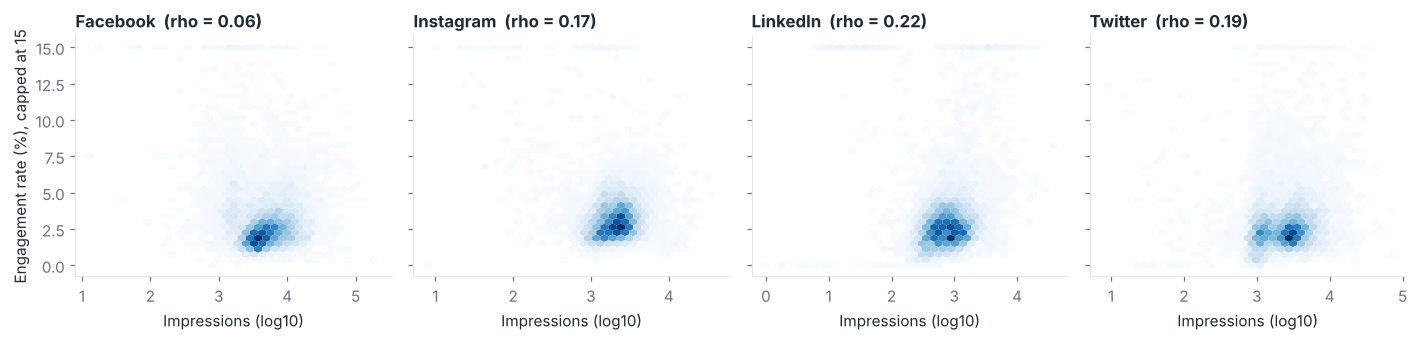

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), sharey=True)
for ax, net in zip(axes, ORDER):
    g = d[d.network == net]
    ax.hexbin(np.log10(g.impressions), g.er.clip(upper=15), gridsize=35, cmap="Blues", mincnt=1, linewidths=0)
    ax.set_title(f"{net}  (rho = {corr.loc[net, 'rho']:.2f})")
    ax.set_xlabel("Impressions (log10)")
    ax.grid(False)
axes[0].set_ylabel("Engagement rate (%), capped at 15")
fig.tight_layout()
fig.savefig(FIG + "04_reach_vs_rate.png")

**Reading it.** The correlation is positive but weak (rho between 0.06 and 0.22). Higher reach does not reliably bring a higher engagement rate, and on Facebook the two are almost unrelated. The direction is also ambiguous: platforms show engaging posts to more people, so engagement may drive impressions rather than the other way round.

## 6. Post features, holding other things constant

Hashtags, links, mentions, questions, length and tone often travel together. For example, campaign posts tend to be longer, carry a campaign hashtag and a link, and are usually photos. Comparing posts with and without hashtags in isolation mixes all of those differences together.

This section fits one model per platform: a Poisson regression of engagements with log(impressions) as an offset, so each coefficient is an **engagement-rate ratio**. It controls for content type, year, time of day, length and tone at the same time, and uses robust standard errors because engagement counts are over-dispersed.

**Tone** is scored with VADER, a lexicon-based sentiment tool that handles emojis and social media text. This measures the tone of the bank's own posts. The export has no audience comments, so it says nothing about how audiences feel.

In [13]:
analyzer = SentimentIntensityAnalyzer()
d["sentiment"] = d["text"].fillna("").map(lambda t: analyzer.polarity_scores(t)["compound"])
d["tone"] = pd.cut(d["sentiment"], [-1.01, -0.05, 0.05, 1.01], labels=["Negative", "Neutral", "Positive"]).astype(str)
d["daypart"] = pd.cut(d["hour"], [-1, 5, 11, 16, 20, 23], labels=["Night", "Morning", "Afternoon", "Evening", "Late"]).astype(str)
d["length"] = pd.cut(d["n_chars"], [-1, 99, 199, 399, 10_000], labels=["Under 100", "100-199", "200-399", "400+"]).astype(str)
pd.crosstab(d["network"], d["tone"], normalize="index").mul(100).round(1)

tone,Negative,Neutral,Positive
network,,,
Facebook,7.3,20.3,72.3
Instagram,6.9,17.4,75.6
LinkedIn,7.3,16.3,76.4
Twitter,7.3,20.3,72.4


A quick face-validity check on the tone scores: the three most negative and three most positive Facebook posts.

In [14]:
fb = d[d.network == "Facebook"].sort_values("sentiment")
pd.concat([fb.head(3), fb.tail(3)])[["sentiment", "text"]].assign(text=lambda x: x.text.str[:140])

,sentiment,text
2622,-0.95,No one deserves any form of violence. Let's be...
301,-0.95,What’s the worst thing that could happen to yo...
213,-0.94,What is the worst thing that could happen to y...
6955,0.99,Growth is a function of effective collaboratio...
691,0.99,We are pleased to inform you that Stanbic IBTC...
4814,0.99,Just as good personal hygiene is essential to ...


Posts scored as negative are mostly risk-framed insurance messages ("what's the worst thing that could happen..."), awareness campaigns (violence, limb loss, cancer) and scam warnings, plus some misreads of Nigerian Pidgin. That is a useful reminder that a lexicon score reflects wording, not intent. Tone is kept as a control and interpreted with that limitation in mind.

**Twitter links.** On Twitter every photo and video tweet carries a `t.co` link added by the platform, so "contains a link" is identical to "contains media". The original link finding for Twitter measured media, not outbound links, so the link term is dropped from the Twitter model.

In [15]:
TERMS = {
    "has_hashtag[T.True]": "Has a hashtag",
    "has_link[T.True]": "Has an outbound link",
    "has_mention[T.True]": "Mentions an account",
    "has_question[T.True]": "Asks a question",
    "C(length, Treatment('100-199'))[T.Under 100]": "Under 100 characters",
    "C(length, Treatment('100-199'))[T.200-399]": "200 to 399 characters",
    "C(length, Treatment('100-199'))[T.400+]": "400+ characters",
    "C(tone, Treatment('Neutral'))[T.Positive]": "Positive tone",
    "C(tone, Treatment('Neutral'))[T.Negative]": "Negative tone",
    "C(content_type, Treatment('Photo'))[T.Video]": "Video (vs photo)",
}
rr_all = []
for net, g in d.groupby("network"):
    link = "" if net == "Twitter" else " + has_link"
    f = ("engagements ~ C(content_type, Treatment('Photo')) + C(year) + C(daypart, Treatment('Morning'))"
         " + has_hashtag + has_mention + has_question + C(length, Treatment('100-199'))"
         " + C(tone, Treatment('Neutral'))" + link)
    rr, model = stats.rate_ratios(g, f)
    rr = rr.loc[rr.index.intersection(TERMS.keys())]
    rr["term"] = rr.index.map(TERMS)
    rr["network"] = net
    rr_all.append(rr)
rr_all = pd.concat(rr_all).reset_index(drop=True)
rr_all["estimate"] = rr_all.apply(lambda r: f"{r.rate_ratio:.2f} ({r.ci_low:.2f} to {r.ci_high:.2f})", axis=1)
rr_all.pivot(index="term", columns="network", values="estimate").reindex(TERMS.values())[ORDER].fillna("not estimable")

network,Facebook,Instagram,LinkedIn,Twitter
term,,,,
Has a hashtag,0.89 (0.85 to 0.93),0.99 (0.95 to 1.03),0.82 (0.71 to 0.94),0.93 (0.86 to 1.01)
Has an outbound link,0.83 (0.78 to 0.88),0.84 (0.80 to 0.88),0.73 (0.63 to 0.84),not estimable
Mentions an account,1.01 (0.94 to 1.07),1.12 (1.06 to 1.19),0.63 (0.55 to 0.73),0.82 (0.75 to 0.90)
Asks a question,1.21 (1.15 to 1.28),0.94 (0.91 to 0.98),1.06 (0.86 to 1.30),1.17 (1.08 to 1.27)
Under 100 characters,1.21 (1.15 to 1.29),1.01 (0.97 to 1.06),1.06 (0.80 to 1.40),1.08 (1.01 to 1.17)
200 to 399 characters,1.04 (0.98 to 1.10),0.93 (0.90 to 0.98),1.33 (1.13 to 1.56),1.23 (1.12 to 1.36)
400+ characters,1.19 (1.08 to 1.31),1.12 (1.02 to 1.23),1.81 (1.44 to 2.27),not estimable
Positive tone,0.94 (0.89 to 0.99),1.04 (1.00 to 1.09),1.03 (0.87 to 1.21),1.01 (0.94 to 1.08)
Negative tone,0.97 (0.89 to 1.07),0.97 (0.91 to 1.03),0.73 (0.61 to 0.86),0.91 (0.81 to 1.02)


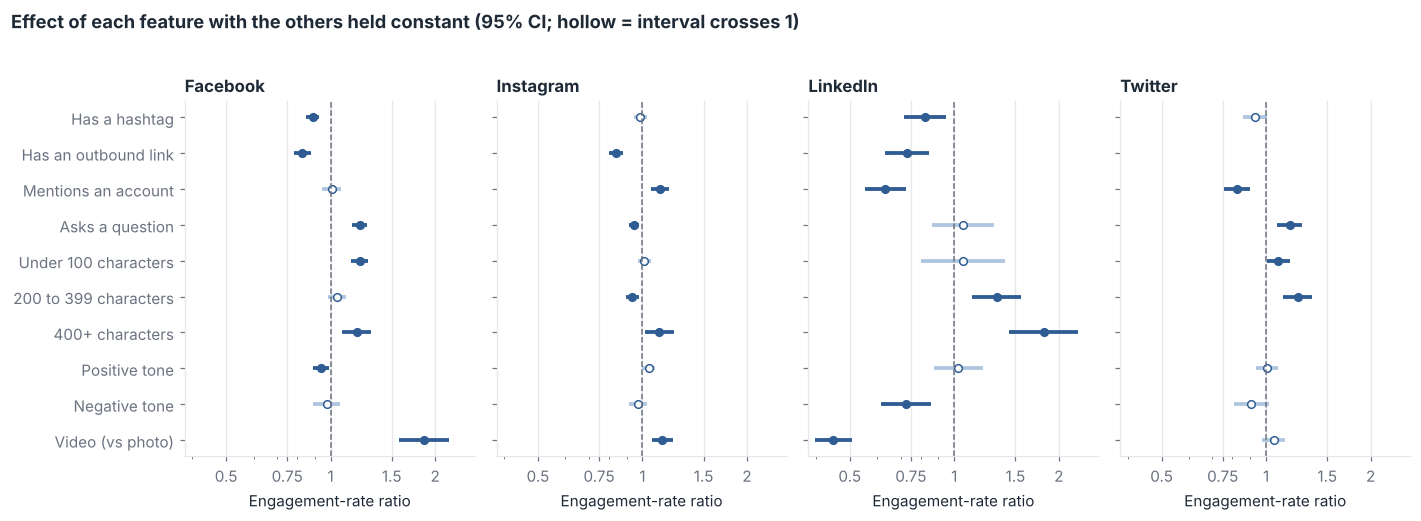

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4.6), sharey=True)
labels = list(TERMS.values())[::-1]
for ax, net in zip(axes, ORDER):
    s = rr_all[rr_all.network == net].set_index("term").reindex(labels)
    y = np.arange(len(labels))
    sig = (s.ci_low > 1) | (s.ci_high < 1)
    ax.hlines(y, s.ci_low, s.ci_high, color=np.where(sig, style.PRIMARY, style.LIGHT), lw=2.5)
    ax.plot(s.rate_ratio, y, "o", color=style.PRIMARY, ms=5)
    ax.plot(s.rate_ratio[~sig], y[~sig], "o", color="white", ms=3)
    ax.axvline(1, color=style.MUTED, lw=1, ls="--")
    ax.set_xscale("log")
    ax.set_xlim(0.38, 2.6)
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xticks([0.5, 0.75, 1, 1.5, 2], ["0.5", "0.75", "1", "1.5", "2"])
    ax.set_yticks(y, labels)
    ax.set_title(net)
    ax.set_xlabel("Engagement-rate ratio")
    ax.grid(axis="y", visible=False)
fig.suptitle("Effect of each feature with the others held constant (95% CI; hollow = interval crosses 1)",
             x=0.01, ha="left", fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIG + "05_feature_rate_ratios.png")

**Reading it** (a ratio of 0.80 means a 20% lower engagement rate per impression than the reference, all else equal)

* **Hashtags do not lift engagement.** The original report said posts with hashtags get "more than 50% additional interactions". Once content type, year, length and the other features are held constant, hashtag posts perform about the same (Instagram, Twitter) or worse (Facebook about 11% lower, LinkedIn about 18% lower). The original comparison summed engagements, so it mostly reflected that hashtag posts were the large majority of posts.
* **Outbound links cost engagement** on Facebook, Instagram and LinkedIn (roughly 16% to 27% lower). This fits the widely reported tendency of platforms to show link posts to fewer people, although this data cannot confirm the mechanism.
* **Video helps on Facebook and hurts on LinkedIn.** The same format choice has opposite effects on different platforms, so a single cross-platform content rule would be wrong.
* **Length**: longer LinkedIn posts (400+ characters) do markedly better, consistent with a professional audience reading more.
* **Questions** lift engagement on Facebook (about 21%) and Twitter (about 17%), which fits their conversational use.
* **Mentioning another account** is associated with lower engagement on LinkedIn (about 37% lower) and Twitter (about 18% lower).
* **Tone** has little effect on Facebook, Instagram or Twitter. On LinkedIn, negatively worded posts do worse, which may reflect the risk-framed insurance and awareness posts noted above.

These are associations in observational data. They are a sound basis for testing a change (for example, A/B testing link placement in the first comment), not proof that the change will work.

## 7. Campaign hashtags, compared fairly

The original analysis noted that a few campaign hashtags appear on thousands of posts and inflate totals. It addressed this by binning hashtags by frequency. A simpler and fairer comparison is each hashtag's year-adjusted engagement index: 1.0 means its posts performed like a typical post from the same platform and year. Only hashtags with at least 50 posts on a platform are shown.

,network,hashtag,posts,index,ci_low,ci_high
8,Facebook,#itcanbe,3341,0.97,0.95,0.99
26,Facebook,#wealthwednesday,338,0.94,0.90,0.99
4,Facebook,#goforit,205,0.88,0.81,0.99
7,Facebook,#hiflstanbicibtc,179,0.64,0.61,0.68
15,Facebook,#powerupmonday,158,0.92,0.88,0.98
24,Facebook,#together4alimb,155,0.96,0.88,1.01
12,Facebook,#movingforward,134,1.08,1.01,1.20
1,Facebook,#bestinsurancedeals,126,0.68,0.65,0.73
38,Instagram,#itcanbe,4134,0.97,0.96,0.98
53,Instagram,#stanbicibtc,737,1.05,1.03,1.06


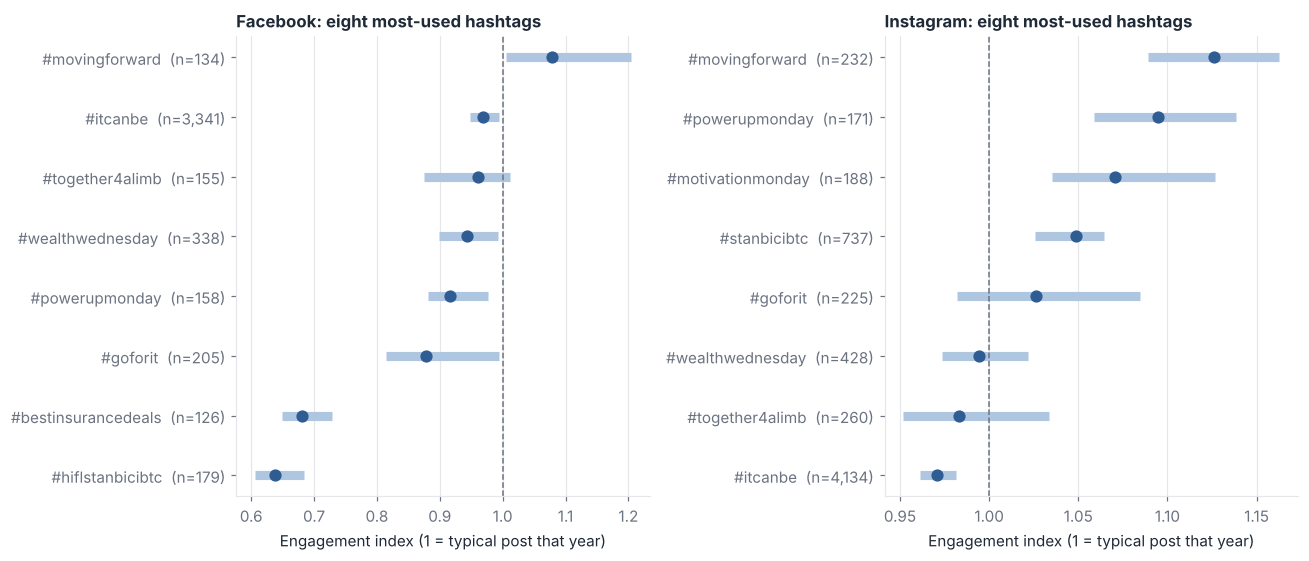

In [17]:
tags = d[["network", "er_index", "hashtags"]].explode("hashtags").dropna(subset=["hashtags"])
rows = []
for (net, tag), g in tags.groupby(["network", "hashtags"]):
    if len(g) >= 50:
        med, lo, hi = stats.median_ci(g.er_index)
        rows.append({"network": net, "hashtag": "#" + tag, "posts": len(g), "index": med, "ci_low": lo, "ci_high": hi})
tag_tbl = pd.DataFrame(rows).sort_values(["network", "index"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, net in zip(axes, ["Facebook", "Instagram"]):
    s = tag_tbl[tag_tbl.network == net].nlargest(8, "posts").sort_values("index")
    y = np.arange(len(s))
    ax.hlines(y, s.ci_low, s.ci_high, color=style.LIGHT, lw=6)
    ax.plot(s["index"], y, "o", color=style.PRIMARY, ms=7)
    ax.axvline(1, color=style.MUTED, lw=1, ls="--")
    ax.set_yticks(y, [f"{h}  (n={n:,})" for h, n in zip(s.hashtag, s.posts)])
    ax.set_title(f"{net}: eight most-used hashtags")
    ax.set_xlabel("Engagement index (1 = typical post that year)")
    ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(FIG + "06_campaign_hashtags.png")
tag_tbl[tag_tbl.network.isin(["Facebook", "Instagram"])].sort_values(["network", "posts"], ascending=[True, False]).groupby("network").head(8)

**Reading it.** The brand line `#ITCANBE`, used on over 3,000 posts per platform, performs slightly below a typical post on both. On Facebook most campaign hashtags sit below 1, and two product campaigns (`#hiflstanbicibtc`, `#bestinsurancedeals`) sit about a third below. On Instagram a few motivational and campaign tags (`#movingforward`, `#powerupmonday`) do 7% to 13% better. Heavy use of a hashtag says nothing about its effect on engagement. Campaign hashtags are better judged on the campaign's own goal (sign-ups, account openings) than on engagement.

## 8. Can post features predict engagement at all?

The original analysis fitted random forests on all the data and read their built-in feature importances, concluding that character count is the main driver everywhere. Two problems: the models were never tested on posts they had not seen, and built-in importances systematically favour continuous variables such as character count.

Here each model is trained on 2017 to 2021 and tested on 2022 to mid-2023. That is a stricter and more realistic test, because the team would use a model to plan future posts. Importance is measured by permutation on the test set.

In [18]:
FEATURES = ["n_chars", "n_words", "n_hashtags", "has_link", "has_mention", "has_question", "hour", "sentiment"]
perf, imps = [], []
for net, g in d.groupby("network"):
    X = pd.get_dummies(g[FEATURES + ["content_type"]], columns=["content_type"]).astype(float)
    y = np.log1p(g["er"])
    train = (g["year"] <= 2021).values
    rf = RandomForestRegressor(n_estimators=400, min_samples_leaf=20, random_state=7, n_jobs=-1)
    rf.fit(X[train], y[train])
    pred = rf.predict(X[~train])
    baseline = np.full((~train).sum(), y[train].median())
    perf.append({"network": net, "train_posts": int(train.sum()), "test_posts": int((~train).sum()),
                 "R2_model": r2_score(y[~train], pred), "R2_baseline": r2_score(y[~train], baseline),
                 "MAE_model": mean_absolute_error(y[~train], pred),
                 "MAE_baseline": mean_absolute_error(y[~train], baseline)})
    pi = permutation_importance(rf, X[~train], y[~train], n_repeats=10, random_state=7, n_jobs=-1)
    imps.append(pd.Series(pi.importances_mean, X.columns, name=net))
perf = pd.DataFrame(perf).set_index("network").loc[ORDER]
perf

,train_posts,test_posts,R2_model,R2_baseline,MAE_model,MAE_baseline
network,,,,,,
Facebook,5250,2429,0.11,-7.39e-02,0.33,0.37
Instagram,5779,2314,-0.04,-1.20e-01,0.30,0.33
LinkedIn,4078,2183,0.03,-5.11e-03,0.37,0.38
Twitter,4872,2281,-0.04,-6.84e-02,0.30,0.29


In [19]:
pd.concat(imps, axis=1)[ORDER].round(3).sort_values("Facebook", ascending=False).head(8)

,Facebook,Instagram,LinkedIn,Twitter
content_type_Video,2.93e-01,-0.00e+00,3.00e-02,1.00e-03
n_chars,2.80e-02,1.00e-02,4.30e-02,-3.00e-03
sentiment,1.00e-02,1.10e-02,-3.00e-03,3.00e-03
n_hashtags,9.00e-03,2.00e-02,1.20e-02,-1.00e-03
has_question,8.00e-03,2.00e-03,-2.00e-03,1.30e-02
has_mention,4.00e-03,0.00e+00,1.80e-02,4.00e-03
content_type_Photo,1.00e-03,3.00e-03,2.00e-02,-3.00e-03
content_type_Link,0.00e+00,NaN,-0.00e+00,-7.00e-03


**Reading it.** On posts the models had not seen, the features explain about 10% of the variation in engagement rate on Facebook and essentially none on Instagram, LinkedIn or Twitter (R squared at or below zero). Where the model does carry signal, it comes from **video versus photo**, not character count. Post wording and formatting are weak levers compared with things this export does not capture, such as paid promotion, creative quality, the topic and timing of campaigns, and platform algorithm changes.

## 9. Summary

| Original claim | What the corrected analysis shows |
|---|---|
| Photos are the most engaging format | Photos lead on totals because they are most of what was posted. Per post, video does best on Facebook, photos on LinkedIn, and format matters little on Instagram. |
| Engagement surged in 2020 because of COVID-19 | Posting volume rose 46% to 65% in 2020. Per-post engagement rose on three platforms and fell on Instagram. The data cannot attribute this to COVID-19. |
| Post at 10am | 10am is when most posts went out, and it performs like a typical post. Early-morning posts do somewhat better on three platforms and are worth testing. |
| Higher impressions lead to higher engagement rates | The correlation is weak (rho 0.06 to 0.22) and its direction is unclear. |
| Hashtags add more than 50% more interactions | With other features held constant, hashtags are neutral or negative. Outbound links lower engagement on three platforms. |
| Character count is the main driver | Features predict little on unseen posts. Where they do, video is the signal. |

### Limitations

* Observational data: every result is an association.
* No paid-promotion flag is available for most platforms, and boosted posts would distort per-post comparisons.
* Timestamps are taken as exported; the time zone is assumed.
* The Instagram export is exactly 10,000 rows, which suggests it may be capped by the export tool.
* Twitter has far fewer posts with metrics in 2021 (593 against about 1,500 in 2020 and 2022), which looks like a gap in the export rather than a real drop in posting.
* Tone is scored on the bank's posts with a general-purpose lexicon, not validated against human coding.